### Step 2-1: Read All Region Image Paths

In this step, all region-level HRTEM images are collected from the dataset directory.  
Only `.png` files located in folders containing **"region"** are selected, while SAED images are excluded.

An **index–filename mapping** is then created to simplify later processing.

Basic metadata is also extracted from the file paths, including the **nanowire ID** and **region ID**, which will be used for grouping and analysis in later steps.

In [1]:
from pathlib import Path

RAW_ROOT = Path("data/raw")

def is_region_png(p):
    parts = [x.lower() for x in p.parts]
    if "saed" in parts:
        return False
    if "region_" not in p.as_posix().lower():
        return False
    return p.suffix.lower() == ".png"

png_files = sorted([p for p in RAW_ROOT.rglob("*.png") if is_region_png(p)])

print("Number of region images:", len(png_files))
for p in png_files:
    print(p)

Number of region images: 7
data\raw\Au2Al\nanowire_01\region_01\Au2Al_wire1_region1.png
data\raw\SnTe\nanowire_01\region_01\SnTe_HRTEM_1.png
data\raw\SnTe\nanowire_01\region_02\SnTe_HRTEM_2.png
data\raw\SnTe\nanowire_01\region_03\SnTe_HRTEM_3.png
data\raw\SnTe\nanowire_01\region_04\SnTe_HRTEM_4.png
data\raw\SnTe\nanowire_02\region_01\SnTe_wire2_region1.png
data\raw\SnTe\nanowire_03\region_01\SnTe_wire3_region1.png


In [2]:
# Step 2-1 (update): index-to-filename mapping
image_names = [p.as_posix() for p in png_files]

print("Index -> filename mapping")
for i, n in enumerate(image_names):
    print(f"Image {i}: {n}")

Index -> filename mapping
Image 0: data/raw/Au2Al/nanowire_01/region_01/Au2Al_wire1_region1.png
Image 1: data/raw/SnTe/nanowire_01/region_01/SnTe_HRTEM_1.png
Image 2: data/raw/SnTe/nanowire_01/region_02/SnTe_HRTEM_2.png
Image 3: data/raw/SnTe/nanowire_01/region_03/SnTe_HRTEM_3.png
Image 4: data/raw/SnTe/nanowire_01/region_04/SnTe_HRTEM_4.png
Image 5: data/raw/SnTe/nanowire_02/region_01/SnTe_wire2_region1.png
Image 6: data/raw/SnTe/nanowire_03/region_01/SnTe_wire3_region1.png


In [3]:
# parse metadata from path
def parse_metadata(p):
    parts = p.parts
    nanowire = [x for x in parts if "nanowire" in x.lower()]
    region = [x for x in parts if "region" in x.lower()]

    return {
        "file": p.as_posix(),
        "nanowire": nanowire[0] if nanowire else "unknown",
        "region": region[0] if region else "unknown"
    }

metadata = [parse_metadata(p) for p in png_files]

print("Metadata preview:")
for m in metadata:
    print(m)

Metadata preview:
{'file': 'data/raw/Au2Al/nanowire_01/region_01/Au2Al_wire1_region1.png', 'nanowire': 'nanowire_01', 'region': 'region_01'}
{'file': 'data/raw/SnTe/nanowire_01/region_01/SnTe_HRTEM_1.png', 'nanowire': 'nanowire_01', 'region': 'region_01'}
{'file': 'data/raw/SnTe/nanowire_01/region_02/SnTe_HRTEM_2.png', 'nanowire': 'nanowire_01', 'region': 'region_02'}
{'file': 'data/raw/SnTe/nanowire_01/region_03/SnTe_HRTEM_3.png', 'nanowire': 'nanowire_01', 'region': 'region_03'}
{'file': 'data/raw/SnTe/nanowire_01/region_04/SnTe_HRTEM_4.png', 'nanowire': 'nanowire_01', 'region': 'region_04'}
{'file': 'data/raw/SnTe/nanowire_02/region_01/SnTe_wire2_region1.png', 'nanowire': 'nanowire_02', 'region': 'region_01'}
{'file': 'data/raw/SnTe/nanowire_03/region_01/SnTe_wire3_region1.png', 'nanowire': 'nanowire_03', 'region': 'region_01'}


### Step 2-2 (Batch Version): Read and Inspect All Region Images

In this step, all region images are loaded to perform a quick data integrity check.  
We verify that each image can be successfully read and inspect basic properties such as image shape and data type.

A sample image is also displayed to visually confirm that the image content is correct and suitable for further analysis.

This step only inspects the images and does not perform any preprocessing.

Au2Al_wire1_region1.png    shape=(314, 364, 4)  dtype=uint8
SnTe_HRTEM_1.png           shape=(422, 448, 4)  dtype=uint8
SnTe_HRTEM_2.png           shape=(682, 730, 4)  dtype=uint8
SnTe_HRTEM_3.png           shape=(684, 708, 4)  dtype=uint8
SnTe_HRTEM_4.png           shape=(423, 442, 4)  dtype=uint8
SnTe_wire2_region1.png     shape=(433, 444, 4)  dtype=uint8
SnTe_wire3_region1.png     shape=(398, 455, 4)  dtype=uint8

Total images: 7


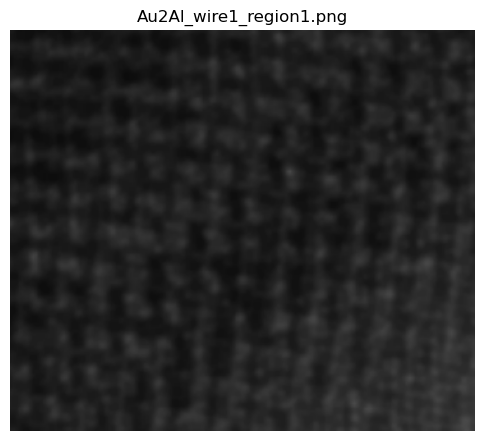

In [4]:
from skimage.io import imread
import matplotlib.pyplot as plt

shapes = []
dtypes = []

for p in png_files:
    img = imread(p)
    shapes.append(img.shape)
    dtypes.append(img.dtype)
    print(f"{p.name:25s}  shape={img.shape}  dtype={img.dtype}")

print("\nTotal images:", len(png_files))

# 抽样显示第一张（你也可以改成其他索引，比如 png_files[3]）
idx = 0
img0 = imread(png_files[idx])

plt.figure(figsize=(6,6))
plt.imshow(img0, cmap="gray")
plt.title(png_files[idx].name)
plt.axis("off")
plt.show()

### Step 2-3: Convert Images to Grayscale

Since some images are stored in RGBA format (4 channels), the alpha channel is removed first and only the RGB channels are kept.

All images are then converted to grayscale to simplify later frequency-domain analysis.  
The processed grayscale images are stored in a list called `gray_images` for subsequent steps.

In [5]:
from skimage.color import rgb2gray

gray_images = []

for p in png_files:
    img = imread(p)

    # If RGBA (4 channels), drop alpha channel -> RGB
    if img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]

    # If already grayscale (2D), keep it; else convert RGB -> gray
    if img.ndim == 2:
        gray = img.astype("float32") / 255.0
    else:
        gray = rgb2gray(img)

    gray_images.append(gray)

print("Total grayscale images:", len(gray_images))
print("Example grayscale shape:", gray_images[0].shape)
print("Gray range example:", gray_images[0].min(), gray_images[0].max())

Total grayscale images: 7
Example grayscale shape: (314, 364)
Gray range example: 0.047058823529411764 0.28627450980392155


### Step 2-4 (Optional): Apply Light Gaussian Blur for Noise Reduction

HRTEM images may contain high-frequency noise.  
A light Gaussian blur can reduce noise while preserving lattice periodicity, which helps stabilize FFT peak detection.

In this step, a small Gaussian filter (e.g., `sigma = 0.6`) is optionally applied to each grayscale image, and the results are stored in `blur_images`.

In [6]:
from skimage.filters import gaussian

SIGMA = 0.6

blur_images = []

for img in gray_images:
    blur = gaussian(img, sigma=SIGMA, preserve_range=True)
    blur_images.append(blur)

print("Total blurred images:", len(blur_images))
print("Example blurred range:", blur_images[0].min(), blur_images[0].max())

Total blurred images: 7
Example blurred range: 0.0470890407516876 0.2854441451917137


### Step 3-1: Perform FFT on All Images

In this step, we compute the **2D Fast Fourier Transform (FFT)** for each preprocessed image to analyze lattice periodicity in reciprocal space.

For each image:
- The FFT is computed using `fft2`.
- The spectrum is centered using `fftshift`.
- The magnitude of the FFT is calculated.
- Log scaling (`log1p`) is applied to improve visualization of diffraction peaks.

The centered FFT results, magnitudes, and log-magnitude spectra are stored for later analysis.

Total FFT images: 7
Example FFT shape: (314, 364)
Example log-mag range: 0.00041133209892418973 9.607363473526165


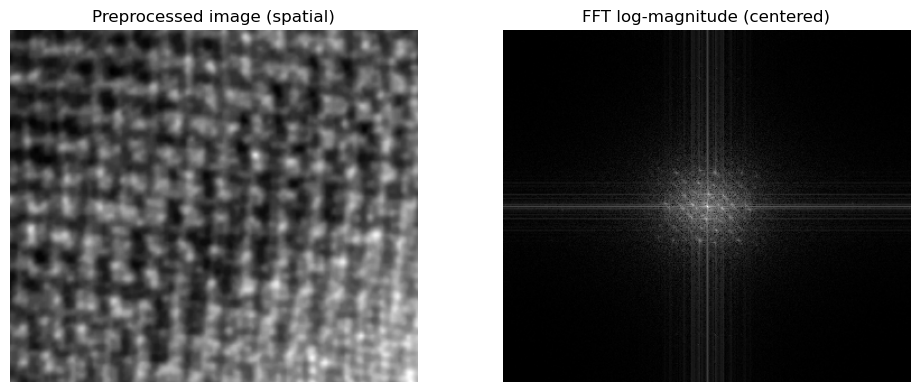

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# choose which preprocessed list to use:
# blur_images (recommended) OR norm_images
imgs_for_fft = blur_images

fft_shift_list = []
fft_mag_list = []
fft_logmag_list = []

for img in imgs_for_fft:
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)
    mag = np.abs(F_shift)
    logmag = np.log1p(mag)   # log(1 + magnitude), same idea as example notebook

    fft_shift_list.append(F_shift)
    fft_mag_list.append(mag)
    fft_logmag_list.append(logmag)

print("Total FFT images:", len(fft_shift_list))
print("Example FFT shape:", fft_shift_list[0].shape)
print("Example log-mag range:", fft_logmag_list[0].min(), fft_logmag_list[0].max())

# quick visualization (same style idea as the example)
idx = 0
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(imgs_for_fft[idx], cmap="gray")
axes[0].set_title("Preprocessed image (spatial)")
axes[0].axis("off")

axes[1].imshow(fft_logmag_list[idx], cmap="gray")
axes[1].set_title("FFT log-magnitude (centered)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Step 3-2: Remove the Central DC Peak

The FFT spectrum contains a very bright **central DC peak** corresponding to the zero-frequency component (average image intensity).  
This peak does not contain structural information and can interfere with peak detection.

To remove its influence, a small circular region around the FFT center is masked and set to zero.  
The filtered FFT magnitude images are stored for subsequent peak detection.

In [8]:
fft_filtered_list = []

radius = 10   # radius of center mask

for mag in fft_mag_list:
    
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    
    Y, X = np.ogrid[:h, :w]
    mask = (Y - cy)**2 + (X - cx)**2 <= radius**2
    
    mag_filtered = mag.copy()
    mag_filtered[mask] = 0
    
    fft_filtered_list.append(mag_filtered)

print("Filtered FFT images:", len(fft_filtered_list))

Filtered FFT images: 7


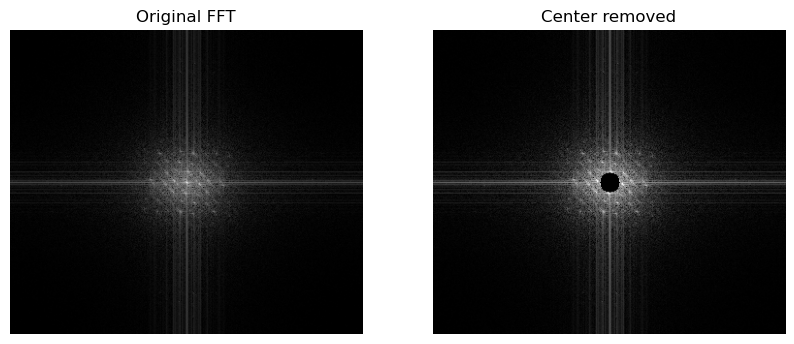

In [9]:
idx = 0

fig, axes = plt.subplots(1,2, figsize=(10,4))

axes[0].imshow(fft_logmag_list[idx], cmap='gray')
axes[0].set_title("Original FFT")

axes[1].imshow(np.log1p(fft_filtered_list[idx]), cmap='gray')
axes[1].set_title("Center removed")

for ax in axes:
    ax.axis("off")

plt.show()

### Step 3-3: Automatically Detect FFT Peaks

In the FFT magnitude spectrum, lattice periodicities appear as **bright diffraction peaks**.

To identify these peaks:
- A radial mask is applied to ignore the central region and outer noise.
- `peak_local_max` is used to detect bright peaks.
- A maximum number of peaks is kept to reduce noise.

The detected peak coordinates for each image are stored for orientation analysis.

In [10]:
from skimage.feature import peak_local_max

fft_peaks_list = []

for mag in fft_filtered_list:

    h, w = mag.shape
    cy, cx = h//2, w//2

    Y, X = np.ogrid[:h, :w]
    r = np.sqrt((Y-cy)**2 + (X-cx)**2)

    # ring mask (remove cross artifacts)
    r_min = 20
    r_max = min(h, w) * 0.45

    ring_mask = (r > r_min) & (r < r_max)

    mag_ring = mag * ring_mask

    peaks = peak_local_max(
        mag_ring,
        min_distance=10,
        num_peaks=20
    )

    fft_peaks_list.append(peaks)

print("Peak sets detected:", len(fft_peaks_list))
print("Example number of peaks:", len(fft_peaks_list[0]))

Peak sets detected: 7
Example number of peaks: 20


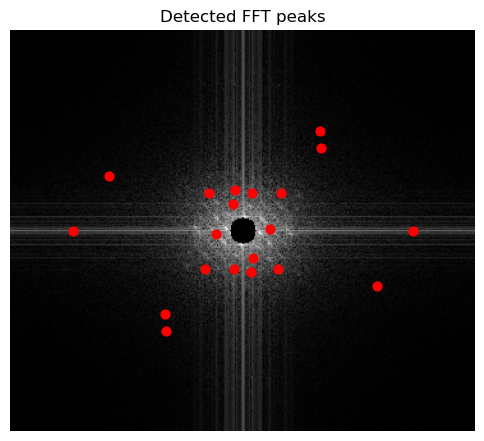

In [11]:
idx = 0

peaks = fft_peaks_list[idx]

plt.figure(figsize=(6,6))
plt.imshow(np.log1p(fft_filtered_list[idx]), cmap="gray")

plt.scatter(peaks[:,1], peaks[:,0], 
            c="red", s=40)

plt.title("Detected FFT peaks")
plt.axis("off")
plt.show()

### Step 3-4: Compute Orientation Angle from FFT Peaks

The lattice orientation can be estimated from the direction of diffraction peaks in reciprocal space.

For each image:
- The FFT center is determined.
- Vectors from the center to detected peaks are computed.
- The strongest peak is selected.
- The orientation angle is calculated using `arctan2(dy, dx)`.

Because FFT directions correspond to reciprocal lattice directions, a 90° rotation is applied to obtain the real lattice orientation.

In [12]:
orientations = []

for peaks, mag in zip(fft_peaks_list, fft_filtered_list):

    h, w = mag.shape
    cy, cx = h//2, w//2

    # peak vectors
    dy = peaks[:,0] - cy
    dx = peaks[:,1] - cx

    # magnitude at peaks
    peak_vals = mag[peaks[:,0], peaks[:,1]]

    # choose strongest peak
    idx = np.argmax(peak_vals)

    dy0 = dy[idx]
    dx0 = dx[idx]

    angle = np.degrees(np.arctan2(dy0, dx0))

    # FFT → real lattice
    angle = angle + 90

    # wrap to [-90,90]
    angle = (angle + 90) % 180 - 90

    # enforce axis symmetry
    if angle > 45:
        angle -= 90
    if angle < -45:
        angle += 90

    orientations.append(angle)

print("Orientation angles:")
for i, a in enumerate(orientations):
    print(f"Image {i}: {a:.2f} degrees")

Orientation angles:
Image 0: -20.85 degrees
Image 1: 14.68 degrees
Image 2: 16.11 degrees
Image 3: 17.70 degrees
Image 4: 17.70 degrees
Image 5: -33.69 degrees
Image 6: -9.93 degrees


### Step 3-5: Normalize Orientation Angles to [-90°, 90°]

The orientation angle obtained from `arctan2` may span a larger range due to directional symmetry.

Since diffraction peaks separated by 180° represent the same lattice orientation, angles are normalized to the range **[-90°, 90°]** to ensure consistent comparison across images.

In [13]:
orientations = []

for peaks, mag in zip(fft_peaks_list, fft_filtered_list):

    h, w = mag.shape
    cy, cx = h//2, w//2

    # peak vectors
    dy = peaks[:,0] - cy
    dx = peaks[:,1] - cx

    # magnitude at peaks
    peak_vals = mag[peaks[:,0], peaks[:,1]]

    # choose strongest peak
    idx = np.argmax(peak_vals)

    dy0 = dy[idx]
    dx0 = dx[idx]

    angle = np.degrees(np.arctan2(dy0, dx0))

    # FFT direction → real lattice direction
    angle = angle + 90

    # wrap to [-90, 90]
    angle = (angle + 90) % 180 - 90

    orientations.append(angle)

print("Orientation angles:")
for i, a in enumerate(orientations):
    print(f"Image {i}: {a:.2f} degrees")

Orientation angles:
Image 0: -20.85 degrees
Image 1: 14.68 degrees
Image 2: 16.11 degrees
Image 3: 17.70 degrees
Image 4: 17.70 degrees
Image 5: -33.69 degrees
Image 6: 80.07 degrees


## Step 4-1: Divide Each HRTEM Image into Fixed-Size Windows  

### Explanation  

Global FFT provides a single orientation value for the entire image, but nanowires may exhibit local orientation variations along the wire.  

To analyze these spatial variations, we divide each HRTEM image into small overlapping windows and perform FFT on each window separately.

In this step we:

1. Define a fixed window size (e.g., **128 × 128 pixels**)  
2. Slide the window across the image with a fixed step (**64 pixels**)  
3. Extract local image patches  
4. Normalize each patch using min–max normalization to the range **[0, 1]**  
5. Store the window patches and their center coordinates  

These windows will later be used for local FFT-based orientation analysis.

In [14]:
window_size = 128
step = 64

windows_all = []
coords_all = []

for img in blur_images:

    h, w = img.shape

    windows = []
    coords = []

    for y in range(0, h - window_size + 1, step):
        for x in range(0, w - window_size + 1, step):

            patch = img[y:y+window_size, x:x+window_size]

            # ---- PATCH NORMALIZATION (important) ----
            pmin = patch.min()
            pmax = patch.max()
            patch = (patch - pmin) / (pmax - pmin + 1e-12)

            windows.append(patch)

            # store window center position
            cy = y + window_size//2
            cx = x + window_size//2
            coords.append((cy, cx))

    windows_all.append(windows)
    coords_all.append(coords)

print("Number of images:", len(windows_all))
print("Example number of windows:", len(windows_all[0]))
print("Window shape:", windows_all[0][0].shape)

Number of images: 7
Example number of windows: 12
Window shape: (128, 128)


## Step 4-2: Compute Local Orientation from Each Window Using FFT

### Explanation

In this step, we compute the local lattice orientation from each image patch using FFT peak detection.

For each patch:

1. Compute the 2D FFT and shift it to center
2. Remove the DC component (central low-frequency region)
3. Detect local maxima (FFT peaks)
4. Apply radial filtering to keep peaks within a valid frequency band
5. Reject FFT cross artifacts near the horizontal/vertical axes
6. Select the strongest remaining peak
7. Convert its position to an orientation angle (wrapped to [-90°, 90°))

If no valid peak is found, the angle is set to `NaN`.

---

### Output per Image

For each image, we store:

- `local_angles_all` → orientation angles of all windows  
- `local_strength_all` → FFT peak intensity (orientation strength)  
- `local_coords_all` → window coordinates  
- `local_valid_ratio` → fraction of windows with valid orientation  

This produces a spatial map of local crystallographic orientation for each HRTEM image.

In [15]:
import numpy as np
from skimage.feature import peak_local_max

def wrap_angle_deg(theta):
    theta = (theta + 180) % 360 - 180
    if theta >= 90:
        theta -= 180
    if theta < -90:
        theta += 180
    return theta


def fft_orientation_from_patch(
    patch,
    dc_radius=8,
    min_dist=6,
    num_peaks=40,
    r_min=12,
    axis_reject_px=3
):
    """
    Robust local orientation from a patch FFT
    """

    F = np.fft.fftshift(np.fft.fft2(patch))
    mag = np.abs(F)

    h, w = mag.shape
    cy, cx = h // 2, w // 2

    # adaptive max radius
    r_max = int(min(patch.shape) * 0.45)

    # remove DC center
    Y, X = np.ogrid[:h, :w]
    dc_mask = (Y - cy)**2 + (X - cx)**2 <= dc_radius**2
    mag[dc_mask] = 0

    # detect peaks
    peaks = peak_local_max(mag, min_distance=min_dist, num_peaks=num_peaks)

    if len(peaks) == 0:
        return np.nan, 0.0

    dy = peaks[:, 0] - cy
    dx = peaks[:, 1] - cx
    dist = np.sqrt(dx**2 + dy**2)

    # radial band filter
    keep = (dist >= r_min) & (dist <= r_max)

    if not np.any(keep):
        return np.nan, 0.0

    peaks = peaks[keep]
    dy = dy[keep]
    dx = dx[keep]

    # reject FFT cross artifacts
    keep2 = (np.abs(dx) > axis_reject_px) & (np.abs(dy) > axis_reject_px)

    if np.any(keep2):
        peaks = peaks[keep2]
        dy = dy[keep2]
        dx = dx[keep2]

    if len(peaks) == 0:
        return np.nan, 0.0

    intensities = mag[peaks[:, 0], peaks[:, 1]]
    best = np.argmax(intensities)

    angle = np.degrees(np.arctan2(dy[best], dx[best]))

    return wrap_angle_deg(angle), float(intensities[best])


# ---------- batch compute ----------
local_angles_all = []
local_strength_all = []
local_valid_ratio = []
local_coords_all = []

for img in blur_images:

    h, w = img.shape
    angles = []
    strengths = []
    coords = []

    for y in range(0, h - window_size + 1, step):
        for x in range(0, w - window_size + 1, step):

            patch = img[y:y+window_size, x:x+window_size]

            ang, s = fft_orientation_from_patch(patch)

            angles.append(ang)
            strengths.append(s)
            coords.append((y, x))

    angles = np.array(angles, dtype=float)
    strengths = np.array(strengths, dtype=float)
    coords = np.array(coords, dtype=int)

    local_angles_all.append(angles)
    local_strength_all.append(strengths)
    local_coords_all.append(coords)

    valid = ~np.isnan(angles)
    local_valid_ratio.append(valid.mean() if len(valid) else 0.0)


print("Done. #images:", len(local_angles_all))
print("Image0 #windows:", len(local_angles_all[0]))
print("Image0 valid ratio:", round(local_valid_ratio[0], 3))
print("Image0 angle range:",
      np.nanmin(local_angles_all[0]),
      np.nanmax(local_angles_all[0]))

Done. #images: 7
Image0 #windows: 12
Image0 valid ratio: 1.0
Image0 angle range: -90.0 54.63753811293094


## Step 4-3: Convert Local Orientation Angles into a 2D Orientation Map

### Explanation

In Step 4-2, we obtained a 1D list of local orientation angles for each image  
(`local_angles_all[i]`) along with their corresponding window coordinates  
(`local_coords_all[i]`).

For visualization and spatial analysis, we reorganize these values into a 2D grid.

- Rows correspond to windows along the **y-direction**
- Columns correspond to windows along the **x-direction**
- Each grid cell stores the orientation angle of one window

### Outputs

- `angle_maps[i]` → 2D orientation map of image *i*
- `grid_shape_list[i]` → grid shape `(ny, nx)`

In [16]:
import numpy as np

angle_maps = []
grid_shape_list = []

for img, angles, coords in zip(blur_images, local_angles_all, local_coords_all):

    h, w = img.shape
    ny = len(range(0, h - window_size + 1, step))
    nx = len(range(0, w - window_size + 1, step))

    angle_map = np.full((ny, nx), np.nan)

    for k, (y, x) in enumerate(coords):

        iy = y // step
        ix = x // step

        angle_map[iy, ix] = angles[k]

    angle_maps.append(angle_map)
    grid_shape_list.append((ny, nx))

print("Example (Image 0):", image_names[0])
print("Grid shape:", grid_shape_list[0])
print("Angle map:\n", np.round(angle_maps[0], 2))

Example (Image 0): data/raw/Au2Al/nanowire_01/region_01/Au2Al_wire1_region1.png
Grid shape: (3, 4)
Angle map:
 [[ 50.19  50.19  50.19  54.64]
 [-90.   -53.88   1.68 -84.43]
 [ 50.19  44.27  45.86   4.4 ]]


## Step 4-4: Overlay Orientation on the Original Image

### Explanation

We overlay the local orientation results directly on the original HRTEM image.

Procedure:

1. Plot the grayscale image
2. Draw semi-transparent rectangles for each window
3. Color each rectangle according to its orientation value
4. Add a colorbar ranging from -90° to 90°

Invalid windows (`NaN`) are skipped.

This visualization shows spatial orientation distribution directly on the nanowire image.

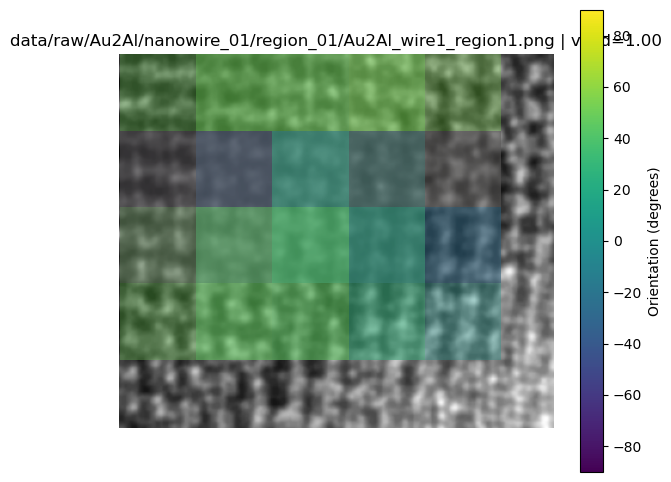

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import numpy as np

idx = 0

img = blur_images[idx]
angles = local_angles_all[idx]
coords = local_coords_all[idx]

fig, ax = plt.subplots(figsize=(7,6))
ax.imshow(img, cmap="gray")

norm = plt.Normalize(-90, 90)
cmap = cm.viridis

for (y, x), ang in zip(coords, angles):
    if np.isnan(ang):
        continue
    rect = patches.Rectangle(
        (x, y), window_size, window_size,
        linewidth=0,
        facecolor=cmap(norm(ang)),
        alpha=0.35
    )
    ax.add_patch(rect)

title = f"{image_names[idx]} | valid={local_valid_ratio[idx]:.2f}"
ax.set_title(title)
ax.axis("off")

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Orientation (degrees)")
plt.show()

## Step 4-5: Generate the Full Orientation Heatmap

### Explanation

To analyze orientation variation independently from the raw image,  
we visualize the 2D orientation map as a heatmap.

- Each cell represents one local FFT window
- Color encodes orientation angle
- Value range is fixed to [-90°, 90°]

This provides a clear spatial representation for statistical analysis.

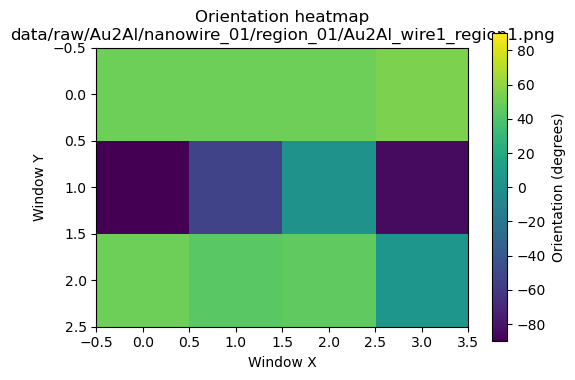

In [18]:
idx = 0

angle_map = angle_maps[idx]

plt.figure(figsize=(6,4))
plt.imshow(angle_map, cmap="viridis", vmin=-90, vmax=90)

plt.title(f"Orientation heatmap\n{image_names[idx]}")
plt.xlabel("Window X")
plt.ylabel("Window Y")

plt.colorbar(label="Orientation (degrees)")
plt.show()

## Step 5-1: Compute Orientation Statistics for Each Image

### Explanation

To quantify orientation variation, we compute statistics from the local angles.

For each image:

- Remove invalid (`NaN`) values
- Convert FFT orientation to real lattice orientation (+90°, wrapped to [-90°, 90°])
- Compute:

  - Mean orientation (circular mean)
  - Standard deviation
  - Variance
  - Valid window ratio

These metrics allow comparison between different nanowire regions.

In [20]:
import numpy as np

orientation_stats = []

for i, angles in enumerate(local_angles_all):

    valid = angles[~np.isnan(angles)]

    # convert FFT → real lattice
    valid = valid + 90
    valid = (valid + 90) % 180 - 90

    n_total = len(angles)
    n_valid = len(valid)
    ratio = n_valid / n_total if n_total else 0.0

    if n_valid:

        # circular mean
        sin_mean = np.mean(np.sin(np.deg2rad(valid)))
        cos_mean = np.mean(np.cos(np.deg2rad(valid)))
        mean_angle = np.rad2deg(np.arctan2(sin_mean, cos_mean))

        std_angle = np.std(valid)
        var_angle = np.var(valid)

    else:
        mean_angle = np.nan
        std_angle = np.nan
        var_angle = np.nan

    orientation_stats.append((mean_angle, std_angle, var_angle, ratio, n_total))

    print(image_names[i])
    print(f" windows total   = {n_total}")
    print(f" valid ratio     = {ratio:.2f}")
    print(f" mean orientation= {mean_angle:.2f} deg")
    print(f" std deviation   = {std_angle:.2f} deg")
    print(f" variance        = {var_angle:.2f}")
    print()

data/raw/Au2Al/nanowire_01/region_01/Au2Al_wire1_region1.png
 windows total   = 12
 valid ratio     = 1.00
 mean orientation= -35.52 deg
 std deviation   = 33.69 deg
 variance        = 1135.19

data/raw/SnTe/nanowire_01/region_01/SnTe_HRTEM_1.png
 windows total   = 30
 valid ratio     = 1.00
 mean orientation= 21.97 deg
 std deviation   = 50.04 deg
 variance        = 2503.81

data/raw/SnTe/nanowire_01/region_02/SnTe_HRTEM_2.png
 windows total   = 90
 valid ratio     = 1.00
 mean orientation= -28.09 deg
 std deviation   = 50.94 deg
 variance        = 2595.25

data/raw/SnTe/nanowire_01/region_03/SnTe_HRTEM_3.png
 windows total   = 90
 valid ratio     = 1.00
 mean orientation= -36.56 deg
 std deviation   = 67.47 deg
 variance        = 4552.36

data/raw/SnTe/nanowire_01/region_04/SnTe_HRTEM_4.png
 windows total   = 25
 valid ratio     = 1.00
 mean orientation= 17.28 deg
 std deviation   = 1.78 deg
 variance        = 3.17

data/raw/SnTe/nanowire_02/region_01/SnTe_wire2_region1.png
 windows 

## Step 5-2: Generate Orientation Heatmaps for All Images

### Explanation

We generate orientation heatmaps for every image in the dataset.

Each heatmap:

- Displays the 2D orientation grid
- Uses consistent color range [-90°, 90°]
- Allows direct comparison across nanowire regions

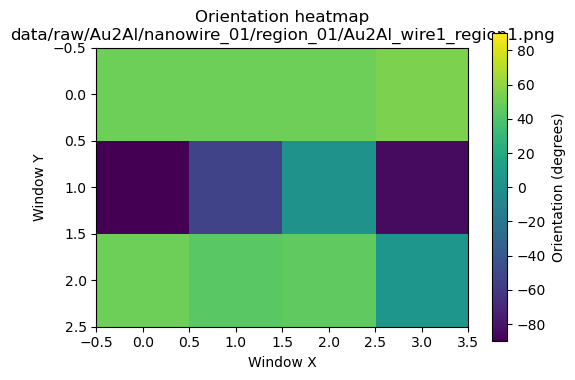

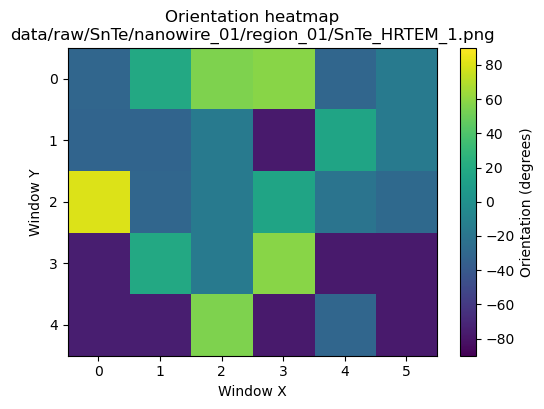

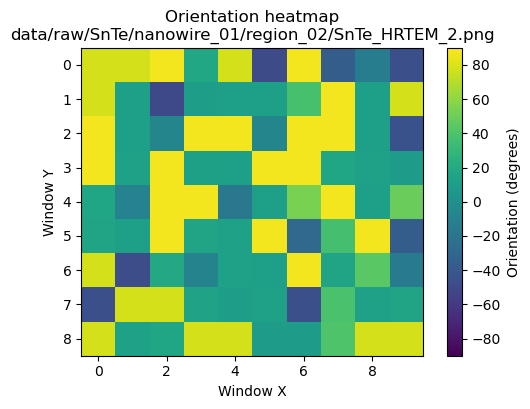

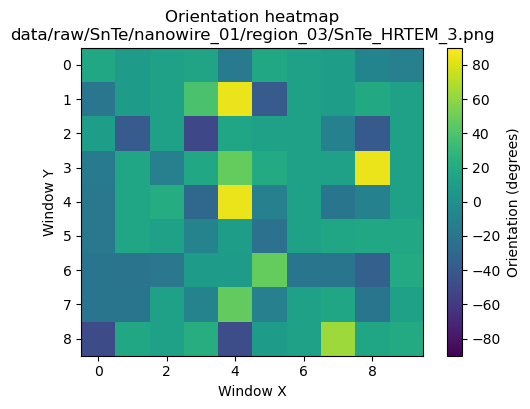

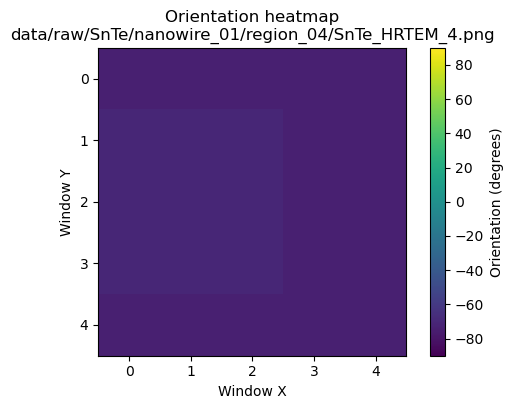

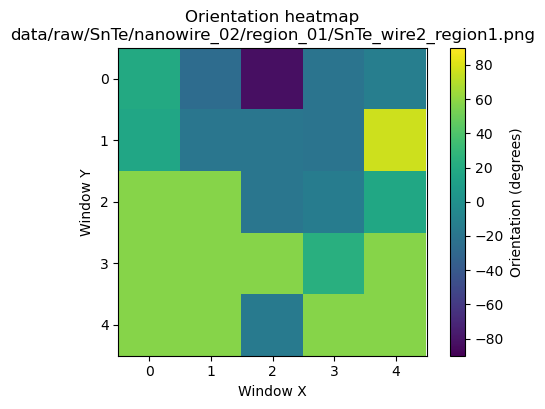

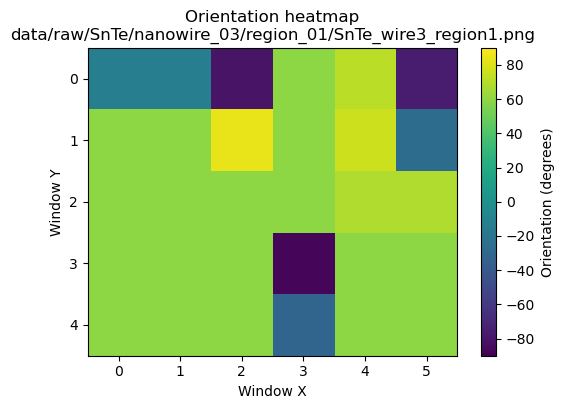

In [21]:
import matplotlib.pyplot as plt

for i, angle_map in enumerate(angle_maps):

    plt.figure(figsize=(6,4))

    plt.imshow(angle_map, cmap="viridis", vmin=-90, vmax=90)

    plt.title(f"Orientation heatmap\n{image_names[i]}")
    plt.xlabel("Window X")
    plt.ylabel("Window Y")

    plt.colorbar(label="Orientation (degrees)")

    plt.show()

## Step 5-3: Generate Orientation Histograms for All Images

### Explanation

To further analyze orientation distribution, we plot histograms  
of the valid local orientation angles.

Interpretation:

- Narrow peak → highly aligned lattice
- Broad distribution → larger orientation disorder

This provides an intuitive comparison of crystallographic alignment.

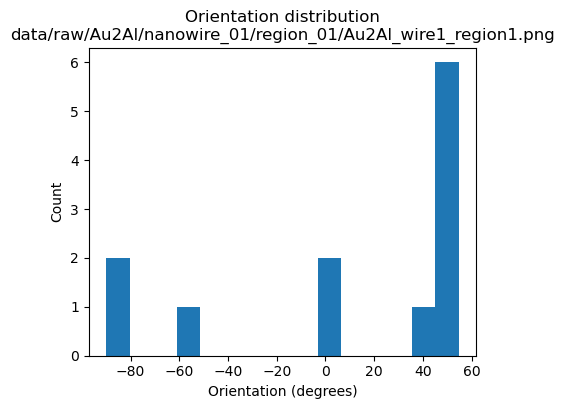

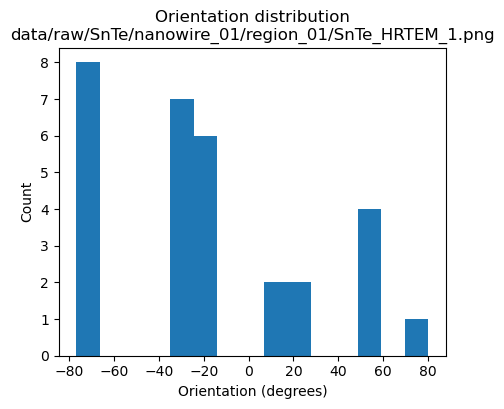

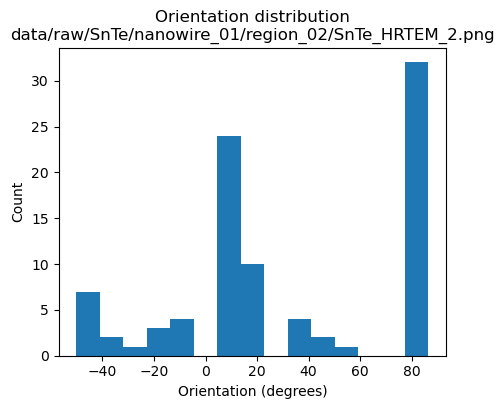

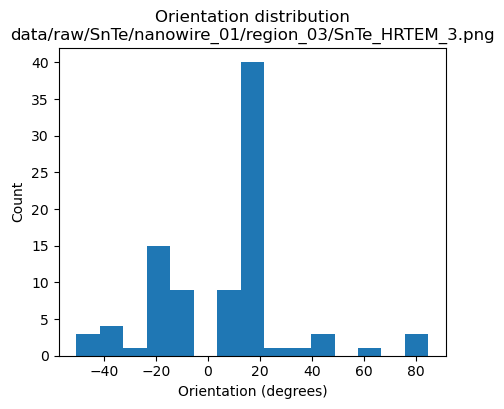

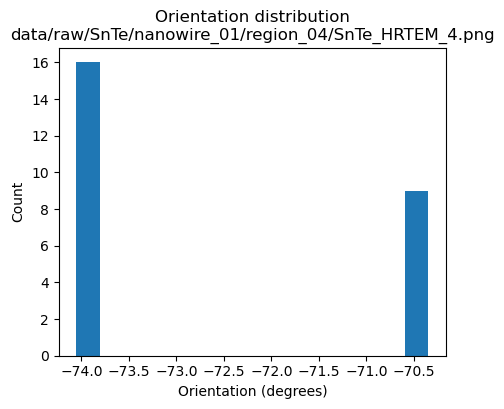

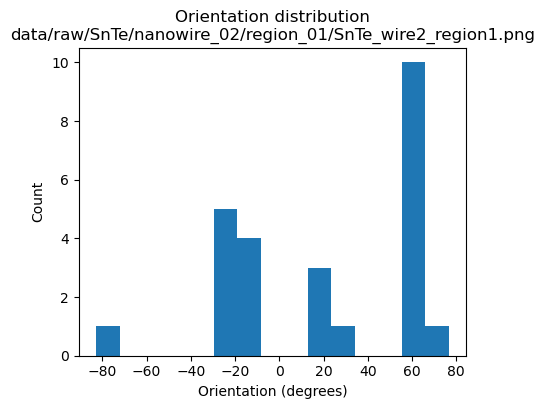

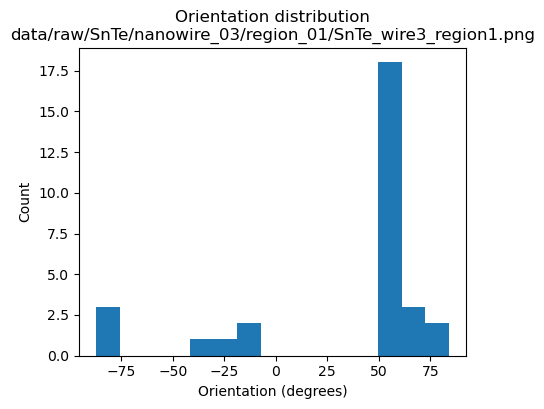

In [22]:
import numpy as np
import matplotlib.pyplot as plt

for i, angles in enumerate(local_angles_all):

    valid = angles[~np.isnan(angles)]

    plt.figure(figsize=(5,4))

    plt.hist(valid, bins=15)

    plt.title(f"Orientation distribution\n{image_names[i]}")
    plt.xlabel("Orientation (degrees)")
    plt.ylabel("Count")

    plt.show()

## Step 5-4: Compare Orientation Variation Across Images

### Explanation

To compare lattice disorder between nanowire regions,  
we visualize the orientation standard deviation for all images.

- Higher std → larger orientation fluctuation
- Lower std → more uniform crystal alignment

This provides a quantitative comparison across the dataset.

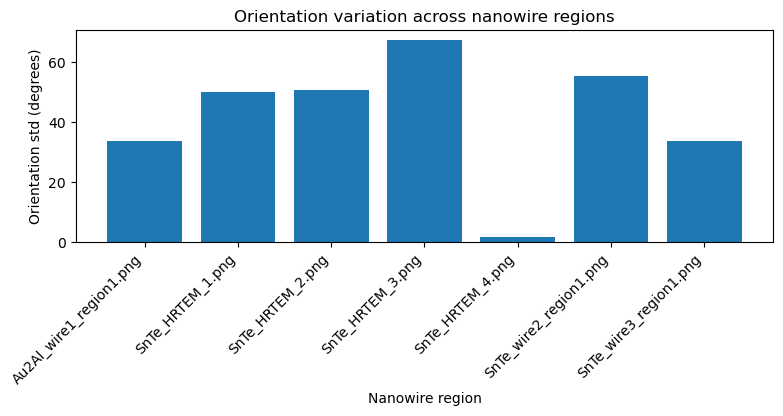

In [23]:
means = [s[0] for s in orientation_stats]
stds = [s[1] for s in orientation_stats]

import matplotlib.pyplot as plt
import numpy as np
import os

x = np.arange(len(means))

# 只保留文件名
labels = [os.path.basename(n) for n in image_names]

plt.figure(figsize=(9,4))

plt.bar(x, stds)

plt.xticks(x, labels, rotation=45, ha="right")

plt.xlabel("Nanowire region")
plt.ylabel("Orientation std (degrees)")

plt.title("Orientation variation across nanowire regions")

plt.subplots_adjust(bottom=0.35)

plt.show()

## Step 6-1: Global Distribution of Orientation Angles from All Windows

### Explanation

To analyze the overall orientation distribution, we combine the local orientation values from selected nanowire regions.

Procedure:

1. Select target images (e.g., specific nanowire regions).
2. Estimate the nanowire axis orientation.
3. Convert FFT angles to real lattice orientation.
4. Compute relative orientation with respect to the wire axis.
5. Apply symmetry folding to keep angles within [-90°, 90°].
6. Filter low-strength FFT windows.
7. Plot the global histogram of relative orientations.

This reveals whether the dataset is dominated by specific lattice directions or shows broad orientation spread.

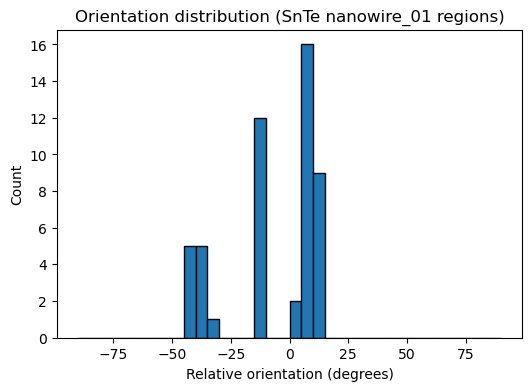

In [24]:
import numpy as np
import matplotlib.pyplot as plt

wire_angles = np.array(orientations)

all_rel_angles = []

# only analyze SnTe nanowire_01
target_indices = [i for i,name in enumerate(image_names)
                  if "nanowire_01" in name]

# compute nanowire axis orientation
wire_axis = np.mean([wire_angles[i] for i in target_indices])

all_strength = np.concatenate([local_strength_all[i] for i in target_indices])
strength_threshold = np.percentile(all_strength,80)

for i in target_indices:

    angles = local_angles_all[i]
    strengths = local_strength_all[i]

    # convert FFT → real lattice
    angles = angles + 90
    angles = (angles + 90) % 180 - 90

    valid = (~np.isnan(angles)) & (strengths > strength_threshold)

    rel = angles[valid] - wire_axis
    rel = (rel + 90) % 180 - 90

    # axis symmetry
    rel = np.where(rel > 45, rel - 90, rel)
    rel = np.where(rel < -45, rel + 90, rel)

    all_rel_angles.append(rel)

all_rel_angles = np.concatenate(all_rel_angles)

plt.figure(figsize=(6,4))

plt.hist(all_rel_angles, bins=36, range=(-90,90), edgecolor="black")

plt.xlabel("Relative orientation (degrees)")
plt.ylabel("Count")

plt.title("Orientation distribution (SnTe nanowire_01 regions)")

plt.show()

## Step 7-1: Intra-Wire Orientation Variance (Internal Consistency)

### Explanation

To evaluate lattice consistency within a single nanowire,  
we combine all local orientation values from its multiple regions.

Procedure:

- Concatenate angles from selected images of the same wire.
- Remove invalid values.
- Convert FFT orientation to real lattice orientation.
- Compute mean, standard deviation, and variance.

This quantifies internal lattice fluctuation within one nanowire.

In [25]:
# SnTe wire 1 images
wire1_idx = [1,2,3,4]

wire1_angles = np.concatenate([local_angles_all[i] for i in wire1_idx])

wire1_valid = wire1_angles[~np.isnan(wire1_angles)]

# convert FFT → real lattice
wire1_valid = wire1_valid + 90
wire1_valid = (wire1_valid + 90) % 180 - 90

print("SnTe nanowire 1")

print("mean orientation =", np.mean(wire1_valid))
print("std orientation =", np.std(wire1_valid))
print("variance =", np.var(wire1_valid))

SnTe nanowire 1
mean orientation = -12.885453654401356
std orientation = 57.80765666120394
variance = 3341.725168659637


## Step 7-2: Compute Orientation Statistics for All Nanowires

### Explanation

To compare different nanowires, we compute statistics separately for each one.

For each nanowire:

1. Combine all its image regions.
2. Remove invalid values.
3. Convert FFT orientation to real lattice orientation.
4. Apply axis symmetry folding.
5. Compute:
   - Circular mean orientation
   - Standard deviation
   - Variance

This provides a quantitative comparison across nanowires.

In [28]:
nanowires = {
    "Au2Al_wire1": [0],
    "SnTe_wire1": [1,2,3,4],
    "SnTe_wire2": [5],
    "SnTe_wire3": [6]
}

nanowire_stats = {}

for name, idx_list in nanowires.items():

    angles = np.concatenate([local_angles_all[i] for i in idx_list])

    valid = angles[~np.isnan(angles)]

    # FFT → real lattice
    valid = valid + 90
    valid = (valid + 90) % 180 - 90

    # axis symmetry folding
    valid = np.where(valid > 45, valid - 90, valid)
    valid = np.where(valid < -45, valid + 90, valid)

    # circular mean
    sin_mean = np.mean(np.sin(np.deg2rad(valid)))
    cos_mean = np.mean(np.cos(np.deg2rad(valid)))
    mean = np.rad2deg(np.arctan2(sin_mean, cos_mean))

    # circular deviation
    diff = ((valid - mean + 90) % 180) - 90
    std = np.std(diff)
    var = np.var(diff)

    nanowire_stats[name] = (mean, std, var)

    print(name)
    print("mean =", round(mean,2))
    print("std =", round(std,2))
    print("var =", round(var,2))
    print()

Au2Al_wire1
mean = -13.05
std = 30.36
var = 921.87

SnTe_wire1
mean = 3.34
std = 19.94
var = 397.66

SnTe_wire2
mean = -17.59
std = 18.59
var = 345.64

SnTe_wire3
mean = -23.07
std = 12.61
var = 159.09



## Step 7-3: Nanowire Orientation Variation Comparison

### Explanation

We compare nanowires by plotting the **standard deviation** of orientation.

- Higher standard deviation → larger internal lattice fluctuation
- Lower standard deviation → more uniform crystal alignment

This visualization highlights differences in lattice stability between nanowires.

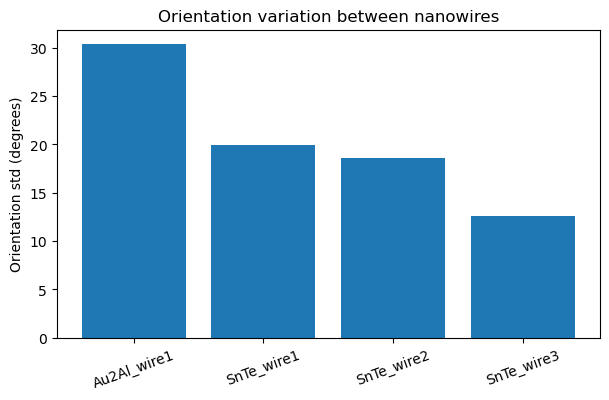

In [29]:
import matplotlib.pyplot as plt

names = list(nanowire_stats.keys())
std_values = [nanowire_stats[n][1] for n in names]

plt.figure(figsize=(7,4))

plt.bar(names, std_values)

plt.ylabel("Orientation std (degrees)")
plt.title("Orientation variation between nanowires")

plt.xticks(rotation=20)

plt.show()

## Step 7-4: Mean Orientation Comparison Between Nanowires

### Explanation

In addition to variation, we compare the **mean lattice orientation**  
for each nanowire.

This reveals whether different nanowires are aligned along different  
crystallographic directions.

The bar plot shows the mean orientation for direct comparison.

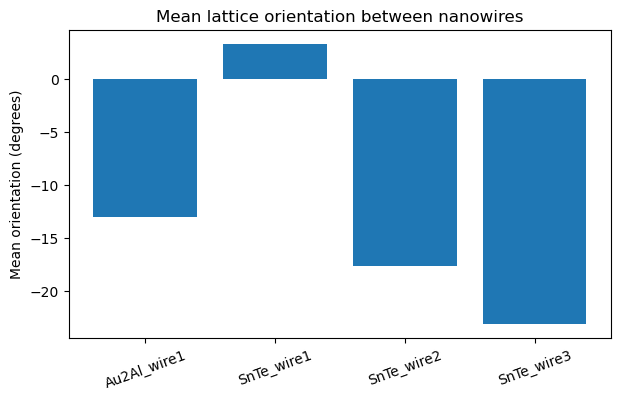

In [30]:
means = [nanowire_stats[n][0] for n in names]

plt.figure(figsize=(7,4))

plt.bar(names, means)

plt.ylabel("Mean orientation (degrees)")
plt.title("Mean lattice orientation between nanowires")

plt.xticks(rotation=20)

plt.show()